In [1]:
# script to reformat merged saturation mutagenesis promoter predictions to VCF format for adding phyloP scores 

In [1]:
# import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
promoter_preds_df = pd.read_csv('../processed_data/mpac.250bp.promoter.preds.with.annotations.parm.act.promoterAI.parm.sat.mut.tsv', sep = '\t')

In [ ]:
# convert to a VCF
# vcf2save = pd.DataFrame({'#CHROM' : promoter_preds_df['chrom'],
#                          'POS' : promoter_preds_df['pos'],
#                          'ID' : promoter_preds_df['id'],
#                          'REF' : promoter_preds_df['ref'],
#                          'ALT' : promoter_preds_df['alt'],
#                          'QUAL' : ['.' for i in range(len(promoter_preds_df))],
#                          'FILTER' : ['.' for i in range(len(promoter_preds_df))],
#                          'INFO' : ['.' for i in range(len(promoter_preds_df))]})

In [9]:
# save to disk
#vcf2save.to_csv('../processed_data/mpac.250bp.promoter.preds.with.annotations.parm.act.promoterAI.parm.sat.mut4vcfAnnotateFromBigWig.vcf', sep = '\t', index = False)

In [3]:
promoter_preds_df.head()

,chrom,pos,id,ref,alt,k562_ref_pred,k562_alt_pred,k562_skew_pred,hepg2_ref_pred,hepg2_alt_pred,...,sknsh_rna_tpm,hepg2_parm_act,k562_parm_act,promoterAI_score,parm_k562_pred,parm_hepg2_pred,parm_mean_pred,parm_k562_emVar,parm_hepg2_emVar,parm_emVar_any
0,chr1,65169,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,A,C,0.368796,0.382817,0.014021,0.367238,0.361899,...,0.0,0.667815,0.166738,0.005,-0.002416,0.002983,0.000283,0,0,0
1,chr1,65169,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,A,G,0.368796,0.373723,0.004927,0.367238,0.363106,...,0.0,0.667815,0.166738,-0.002,-0.001053,0.004086,0.001516,0,0,0
2,chr1,65169,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,A,T,0.368796,0.355564,-0.013233,0.367238,0.344585,...,0.0,0.667815,0.166738,-0.003,-0.001701,-0.000167,-0.000934,0,0,0
3,chr1,65170,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,G,A,0.287499,0.341029,0.053531,0.352586,0.411632,...,0.0,0.667815,0.166738,0.010,0.000088,0.000730,0.000409,0,0,0
4,chr1,65170,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,G,C,0.287499,0.300818,0.013319,0.352586,0.341317,...,0.0,0.667815,0.166738,0.002,0.000470,-0.000271,0.000100,0,0,0


In [4]:
phyloCheck = pd.read_csv('../processed_data/mpac.250bp.promoter.preds.with.annotations.parm.act.promoterAI.parm.sat.mut4.phyloP.annotated.vcf', sep = '\t', comment = '#', header = None)

In [5]:
print(len(phyloCheck))

12390069


In [6]:
# drop missing values
phyloCheck = phyloCheck[phyloCheck[7] != '.']

In [7]:
print(len(phyloCheck))

12303966


In [8]:
phyloDict = dict(zip([(':').join([chrom, str(pos), ref, alt])for chrom, pos, ref, alt in zip(phyloCheck[0], phyloCheck[1], phyloCheck[3], phyloCheck[4])],
                     [float(i.split('=')[-1]) for i in phyloCheck[7]]))

In [9]:
promoter_preds_df.loc[:, 'grab_id'] = [(':').join([chrom, str(pos), ref, alt]) for chrom, pos, ref, alt in zip(promoter_preds_df['chrom'], promoter_preds_df['pos'], promoter_preds_df['ref'], promoter_preds_df['alt'])]

In [10]:
promoter_preds_df.loc[:, 'phyloP'] = [phyloDict.get(i) for i in promoter_preds_df['grab_id']]
proDrop = promoter_preds_df.dropna()

In [11]:
print(len(proDrop))

11886648


<Axes: xlabel='phyloP', ylabel='Count'>

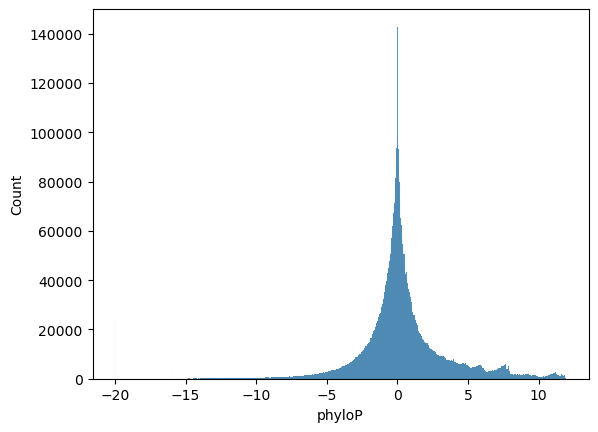

In [12]:
sns.histplot(proDrop['phyloP'])

In [44]:
# let's try binning variants by skew and getting mean phyloP score
# k562
k_filter = proDrop.filter(['phyloP', 'k562_skew_pred'])
k_filter.loc[:, 'mpac_k562_bin'] = pd.cut(k_filter['k562_skew_pred'], [-1.5, -1, -0.5, -0.25, -0.05, 0.05, 0.25, 0.5, 0.75, 1, 1.5])
k_posphylo = k_filter[k_filter['phyloP'] < 0]

In [34]:
proAI_filter = proDrop.filter(['phyloP', 'promoterAI_score'])
proAI_filter.loc[:, 'promoterAI_bin'] = pd.cut(proAI_filter['promoterAI_score'], [-1, -0.75, -0.5, -0.25, -0.05, 0.05, 0.25, 0.5, 0.75, 1])
proAI_posphylo = proAI_filter[proAI_filter['phyloP'] >= 0]

In [38]:
parm_k_filter = proDrop.filter(['phyloP', 'parm_k562_pred'])
parm_k_filter.loc[:, 'parm_k562_bin'] = pd.cut(parm_k_filter['parm_k562_pred'], [-1, -0.5, -0.25, -0.05, 0.05, 0.25, 0.5, 0.75, 1])
parm_posphylo = parm_k_filter[parm_k_filter['phyloP'] >=0]

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, '(-1.5, -1.0]'),
  Text(1, 0, '(-1.0, -0.5]'),
  Text(2, 0, '(-0.5, -0.25]'),
  Text(3, 0, '(-0.25, -0.05]'),
  Text(4, 0, '(-0.05, 0.05]'),
  Text(5, 0, '(0.05, 0.25]'),
  Text(6, 0, '(0.25, 0.5]'),
  Text(7, 0, '(0.5, 0.75]'),
  Text(8, 0, '(0.75, 1.0]'),
  Text(9, 0, '(1.0, 1.5]')])

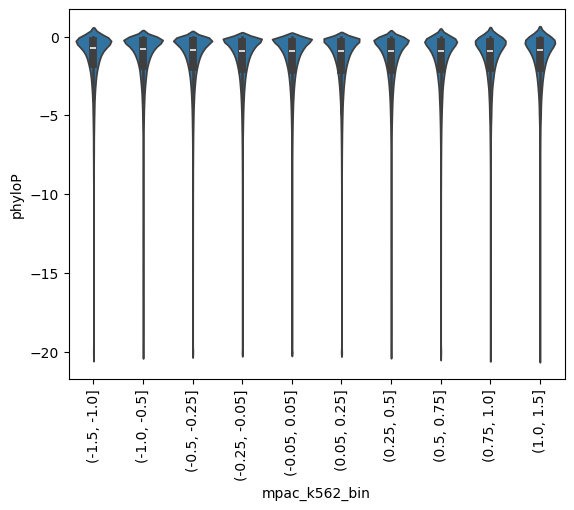

In [46]:
sns.violinplot(
    data = k_posphylo,
    x = 'mpac_k562_bin',
    y = 'phyloP'
)
plt.xticks(rotation = 90)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, '(-1.5, -1.0]'),
  Text(1, 0, '(-1.0, -0.5]'),
  Text(2, 0, '(-0.5, -0.25]'),
  Text(3, 0, '(-0.25, -0.05]'),
  Text(4, 0, '(-0.05, 0.05]'),
  Text(5, 0, '(0.05, 0.25]'),
  Text(6, 0, '(0.25, 0.5]'),
  Text(7, 0, '(0.5, 0.75]'),
  Text(8, 0, '(0.75, 1.0]'),
  Text(9, 0, '(1.0, 1.5]')])

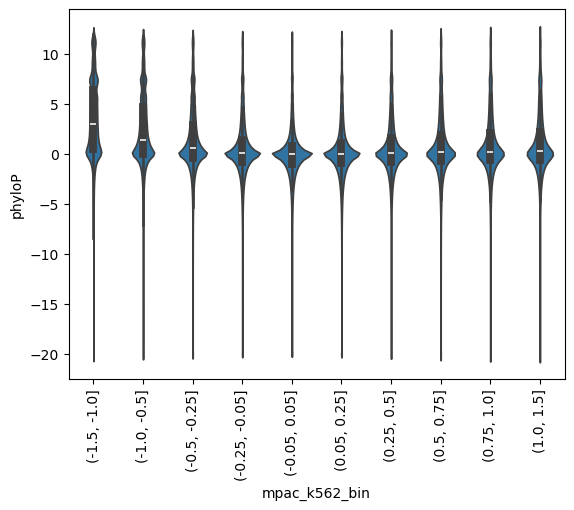

In [43]:
sns.violinplot(
    data = k_filter,
    x = 'mpac_k562_bin',
    y = 'phyloP'
)
plt.xticks(rotation = 90)

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, '(-1.0, -0.75]'),
  Text(1, 0, '(-0.75, -0.5]'),
  Text(2, 0, '(-0.5, -0.25]'),
  Text(3, 0, '(-0.25, -0.05]'),
  Text(4, 0, '(-0.05, 0.05]'),
  Text(5, 0, '(0.05, 0.25]'),
  Text(6, 0, '(0.25, 0.5]'),
  Text(7, 0, '(0.5, 0.75]'),
  Text(8, 0, '(0.75, 1.0]')])

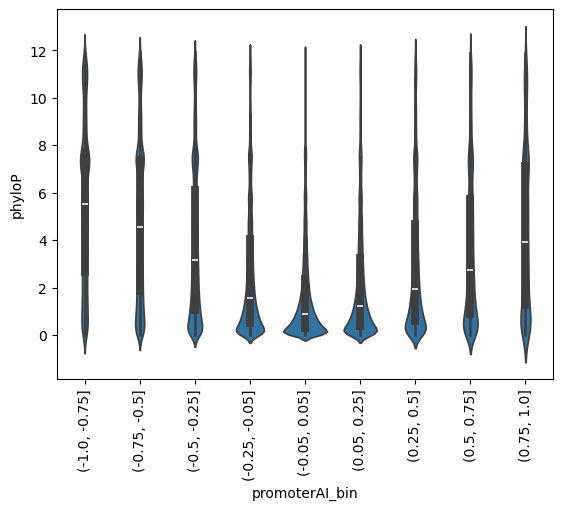

In [33]:
sns.violinplot(
    data = proAI_posphylo,
    x = 'promoterAI_bin',
    y = 'phyloP'
)
plt.xticks(rotation=90)

In [15]:
k_filter

,phyloP,k562_skew_pred,mpac_k562_bin
0,2.679,0.014021,"(-0.05, 0.05]"
1,2.679,0.004927,"(-0.05, 0.05]"
2,2.679,-0.013233,"(-0.05, 0.05]"
3,-0.117,0.053531,"(0.05, 0.25]"
4,-0.117,0.013319,"(-0.05, 0.05]"
...,...,...,...
12390064,-0.500,-0.004690,"(-0.05, 0.05]"
12390065,-0.500,0.173852,"(0.05, 0.25]"
12390066,0.803,0.010397,"(-0.05, 0.05]"
12390067,0.803,0.024360,"(-0.05, 0.05]"


<Axes: xlabel='phyloP'>

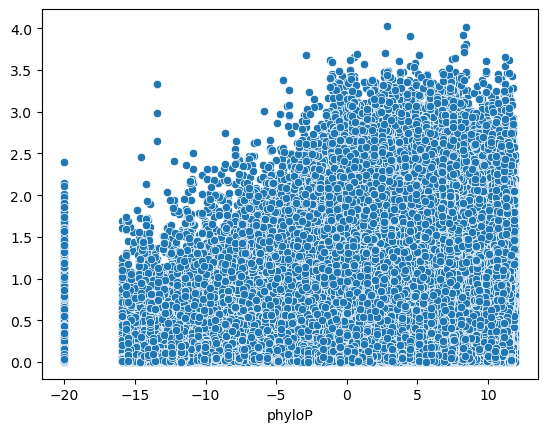

In [29]:
sns.scatterplot(
    data = proDrop,
    x = 'phyloP',
    y = [abs(i) for i in proDrop['k562_skew_pred']]
)

In [26]:
stats.pearsonr(x=proDrop['phyloP'], y=[abs(i) for i in proDrop['hepg2_skew_pred']])

PearsonRResult(statistic=np.float64(0.20907625739361652), pvalue=np.float64(0.0))

In [20]:
stats.pearsonr(x=proDrop['phyloP'], y=[abs(i) for i in proDrop['k562_skew_pred']])

PearsonRResult(statistic=np.float64(0.20907625739361652), pvalue=np.float64(0.0))

In [21]:
stats.pearsonr(x=proDrop['phyloP'], y=[abs(i) for i in proDrop['sknsh_skew_pred']])

PearsonRResult(statistic=np.float64(0.20724554933412437), pvalue=np.float64(0.0))

In [16]:
stats.pearsonr(x=proDrop['phyloP'], y=[abs(i) for i in proDrop['promoterAI_score']])

PearsonRResult(statistic=np.float64(0.24176623714833123), pvalue=np.float64(0.0))

In [22]:
stats.pearsonr(x=proDrop['phyloP'], y=[abs(i) for i in proDrop['parm_k562_pred']])

PearsonRResult(statistic=np.float64(0.15405068226752672), pvalue=np.float64(0.0))

In [23]:
stats.pearsonr(x=proDrop['phyloP'], y=[abs(i) for i in proDrop['parm_hepg2_pred']])

PearsonRResult(statistic=np.float64(0.13663625303947902), pvalue=np.float64(0.0))